In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 10.4 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

## Load in Data

In [ ]:
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_alt_seg_imu_sensor_df.csv"

interpolated_final_df = pd.read_csv(path)

In [ ]:

lower_body_imu_sensor_locations = ['Pelvis', 'RightUpperLeg', 'RightLowerLeg', 'LeftUpperLeg', 'LeftLowerLeg', 'RightFoot', 'LeftFoot']

In [ ]:
# retain the sensors that are in the luo_imu_sensor_locations list
interpolated_final_df = interpolated_final_df[interpolated_final_df['sensor_location'].isin(lower_body_imu_sensor_locations)]

In [ ]:
interpolated_final_df['gait_cycle_id'] = interpolated_final_df['participant_id'].astype(str) + '_' + interpolated_final_df['task'].astype(str) + '_' + interpolated_final_df['segment_count'].astype(str)

In [ ]:
# Rename 'pavement_up' to 'stairs_up' and 'pavement_down' to 'stairs_down'
interpolated_final_df['walk_mode'] = interpolated_final_df['walk_mode'].replace({'pavement_up': 'stairs_up', 'pavement_down': 'stairs_down'})

In [ ]:
interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']]* 1000

In [ ]:
# make columns in df into type int
interpolated_final_df[['time', 'segment_count', 'participant_id', 'task', 'walk_mode']] = interpolated_final_df[['time', 'segment_count', 'participant_id', 'task', 'walk_mode']].astype(int)
interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z',
                                                                                                                                                                      'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].astype(int)


In [ ]:
interpolated_final_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [ ]:
interpolated_final_df.head()

,time,participant_id,task,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,segment_count,walk_mode,sensor_location,gait_cycle_id
0,0,1,0,-2857,-923,-1930,-401,804,147,1,4,LeftFoot,1.0_0.0_1.0
80,0,1,0,-9046,2399,-4681,408,1891,834,1,4,LeftLowerLeg,1.0_0.0_1.0
160,0,1,0,13051,3724,7346,765,-45,-434,1,4,LeftUpperLeg,1.0_0.0_1.0
240,0,1,0,-3558,-1303,-356,295,-253,1032,1,4,Pelvis,1.0_0.0_1.0
320,0,1,0,8593,-7461,3174,2996,8846,824,1,4,RightFoot,1.0_0.0_1.0


In [ ]:
import random

number_list = list(interpolated_final_df['participant_id'].unique())

# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[19, 18]
[16, 12]
[1, 2, 3, 4, 5, 7, 8, 10, 13, 14, 15, 17, 22, 23, 24, 25]


In [ ]:
train = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(train_list)]
val = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(val_three_numbers)]
test = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(test_three_numbers)]

In [ ]:
# retain only the first instance of gait_cycle_id
train_unique = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [ ]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_unique['walk_mode'].value_counts().min())

In [ ]:
min_samples

2990

In [ ]:
# Downsample to balance classes
balanced_gait_cycles = (
    train_unique.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)

<ipython-input-18-e6181ac3816b>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [ ]:
print(balanced_gait_cycles['walk_mode'].value_counts())

walk_mode
0    2990
1    2990
2    2990
3    2990
4    2990
Name: count, dtype: int64


In [ ]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [ ]:
filtered_interpolated_final_df.head()

,time,participant_id,task,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,segment_count,walk_mode,sensor_location,gait_cycle_id
0,1400,1,0,1163,654,2812,307,1203,-16,5,4,LeftFoot,1.0_0.0_5.0
1,1400,1,0,9849,-4157,-1716,687,2032,152,5,4,LeftLowerLeg,1.0_0.0_5.0
2,1400,1,0,-1456,-1555,-2247,579,1790,1551,5,4,LeftUpperLeg,1.0_0.0_5.0
3,1400,1,0,535,925,-1610,191,-415,541,5,4,Pelvis,1.0_0.0_5.0
4,1400,1,0,-28612,12152,4383,-2758,-6520,988,5,4,RightFoot,1.0_0.0_5.0


In [ ]:
filtered_interpolated_final_df['participant_id'].unique()

array([ 1,  2,  3,  4,  5,  7,  8, 10, 13, 14, 15, 17, 22, 23, 24, 25])

In [ ]:
filtered_interpolated_final_df['gait_cycle_id'].value_counts()

,count
gait_cycle_id,
1.0_0.0_5.0,560
15.0_1.0_1147.0,560
15.0_1.0_1024.0,560
15.0_1.0_1025.0,560
15.0_1.0_1027.0,560
...,...
7.0_1.0_223.0,560
7.0_1.0_243.0,560
7.0_1.0_247.0,560


In [ ]:
train = filtered_interpolated_final_df.copy()

In [ ]:
total_num = 0
for p in  train['participant_id'].unique():
    participant_1 = train[train['participant_id'] == p]
    pant_num = participant_1['segment_count'].nunique()
    total_num += pant_num
print(total_num)

13073


In [ ]:
test.head()

,time,participant_id,task,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,segment_count,walk_mode,sensor_location,gait_cycle_id
38951040,0,18,0,-906,4629,-3388,1260,360,72,1,4,LeftFoot,18.0_0.0_1.0
38951120,0,18,0,-745,1814,494,2448,1319,-1170,1,4,LeftLowerLeg,18.0_0.0_1.0
38951200,0,18,0,-11398,22377,-6593,-784,-453,-1358,1,4,LeftUpperLeg,18.0_0.0_1.0
38951280,0,18,0,572,-4128,2966,96,-569,771,1,4,Pelvis,18.0_0.0_1.0
38951360,0,18,0,871,-4935,5676,2801,1112,262,1,4,RightFoot,18.0_0.0_1.0


In [ ]:
test.groupby('gait_cycle_id').count()

,time,participant_id,task,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,segment_count,walk_mode,sensor_location
gait_cycle_id,,,,,,,,,,,,
18.0_0.0_1.0,560,560,560,560,560,560,560,560,560,560,560,560
18.0_0.0_100.0,560,560,560,560,560,560,560,560,560,560,560,560
18.0_0.0_1000.0,560,560,560,560,560,560,560,560,560,560,560,560
18.0_0.0_1001.0,560,560,560,560,560,560,560,560,560,560,560,560
18.0_0.0_1002.0,560,560,560,560,560,560,560,560,560,560,560,560
...,...,...,...,...,...,...,...,...,...,...,...,...
19.0_2.0_995.0,560,560,560,560,560,560,560,560,560,560,560,560
19.0_2.0_996.0,560,560,560,560,560,560,560,560,560,560,560,560
19.0_2.0_997.0,560,560,560,560,560,560,560,560,560,560,560,560


In [ ]:
le = LabelEncoder()

train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

<ipython-input-28-b990848ca3d9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
<ipython-input-28-b990848ca3d9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['sensor_location'] = le.fit_transform(val['sensor_location'])
<ipython-input-28-b990848ca3d9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [ ]:
print(train.isnull().sum())

time                 0
participant_id       0
task                 0
acceleration_x       0
acceleration_y       0
acceleration_z       0
angularVelocity_x    0
angularVelocity_y    0
angularVelocity_z    0
segment_count        0
walk_mode            0
sensor_location      0
gait_cycle_id        0
dtype: int64


In [ ]:
def preprocess_data(df):
    # Initialize a list to hold data for each sensor location
    sensor_data_dict = {sensor: [] for sensor in df['sensor_location'].unique()}
    all_labels_y = []  # For storing labels for each gait cycle

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Process each sensor location
        for sensor_location, sensor_group in group_data.groupby('sensor_location'):
            # Extract the six IMU features
            sensor_array = sensor_group[['acceleration_x', 'acceleration_y', 'acceleration_z',
                                         'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].values

            # Pad or truncate to ensure length of 80
            if len(sensor_array) < 80:
                padding = np.zeros((80 - len(sensor_array), 6))  # Pad with 6 zeros
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                sensor_array = sensor_array[:80]

            # Append the processed sensor data for the current sensor location
            sensor_data_dict[sensor_location].append(sensor_array)

        # Extract walk mode labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding
        all_labels_y.append(walk_mode_data)

    # Convert sensor data for each sensor location into a NumPy array with shape [x, 80, 6]
    all_sensor_data = [np.array(sensor_data_dict[sensor]) for sensor in sorted(sensor_data_dict.keys())]

    # Convert labels to a NumPy array with shape [x, 80]
    all_labels_x = np.array(all_sensor_data)
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_sensor_data, all_labels_y


In [ ]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [ ]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [ ]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [ ]:
train_all_data_x_np = np.array(train_all_data_x)
val_all_data_x_np = np.array(val_all_data_x)
test_all_data_x_np = np.array(test_all_data_x)

In [ ]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [ ]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [ ]:
train_all_labels_y[0]

array([0., 0., 1., 0., 0.])

In [ ]:
train_all_data_x_np.shape, train_all_labels_y.shape, val_all_data_x_np.shape, val_all_labels_y.shape, test_all_data_x_np.shape, test_all_labels_y.shape

((7, 14950, 80, 6),
 (14950, 5),
 (7, 9544, 80, 6),
 (9544, 5),
 (7, 8652, 80, 6),
 (8652, 5))

In [ ]:
train_all_data_x_np.shape, train_all_labels_y.shape

((7, 14950, 80, 6), (14950, 5))

In [ ]:
val_all_data_x_np.shape, val_all_labels_y.shape

((7, 9544, 80, 6), (9544, 5))

In [ ]:
test_all_data_x_np.shape, test_all_labels_y.shape

((7, 8652, 80, 6), (8652, 5))

In [ ]:
train_X = train_all_data_x_np
train_Y = train_all_labels_y

val_X = val_all_data_x_np
val_Y = val_all_labels_y

test_X = test_all_data_x_np
test_Y = test_all_labels_y

In [ ]:
n_obs, n_timesteps, n_features, n_classes = train_X[0].shape[0], train_X[0].shape[1], train_X[0].shape[2], train_Y.shape[1]

In [ ]:
n_obs, n_timesteps, n_features, n_classes

(14950, 80, 6, 5)

In [ ]:
train_X_list = [train_all_data_x_np[i] for i in range(train_all_data_x_np.shape[0])]
train_Y_list = [train_all_labels_y for i in range(train_all_data_x_np.shape[0])]

val_X_list = [val_all_data_x_np[i] for i in range(val_all_data_x_np.shape[0])]
val_Y_list = [val_all_labels_y for i in range(val_all_data_x_np.shape[0])]

test_X_list = [test_all_data_x_np[i] for i in range(test_all_data_x_np.shape[0])]

test_Y_list = [test_all_labels_y for i in range(test_all_data_x_np.shape[0])]

# Print the shape of each item in the list to verify
for idx, sensor_data in enumerate(train_X_list):
    print(f"Sensor {idx+1} shape: {sensor_data.shape}")
    print(f"Label {idx+1} shape: {train_Y_list[idx].shape}")
    print()


Sensor 1 shape: (14950, 80, 6)
Label 1 shape: (14950, 5)

Sensor 2 shape: (14950, 80, 6)
Label 2 shape: (14950, 5)

Sensor 3 shape: (14950, 80, 6)
Label 3 shape: (14950, 5)

Sensor 4 shape: (14950, 80, 6)
Label 4 shape: (14950, 5)

Sensor 5 shape: (14950, 80, 6)
Label 5 shape: (14950, 5)

Sensor 6 shape: (14950, 80, 6)
Label 6 shape: (14950, 5)

Sensor 7 shape: (14950, 80, 6)
Label 7 shape: (14950, 5)



## hyperparameter tuning

In [ ]:
# import numpy as np
# from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional, Concatenate
# from tensorflow.keras.callbacks import EarlyStopping

# # Define input shape and number of inputs
# input_shape = (n_timesteps, n_features)  # Adjust these values based on your data
# num_classes = n_classes
# number_of_sensors = len(train_X_list)  # Assuming you have a list for each sensor's data

# # Define search space for hyperparameters
# space = {
#     'dropout_rate': hp.uniform('dropout_rate', 0.2, 0.5),
#     'lstm_dropout_rate': hp.uniform('lstm_dropout_rate', 0.2, 0.5),
#     'num_units_lstm': hp.choice('num_units_lstm', [32, 64, 128]),
#     'num_filters_cnn': hp.choice('num_filters_cnn', [64, 128, 256]),
# }

# # Define objective function
# def objective(params):
#     # Clear previous Keras sessions to avoid memory issues during hyperparameter optimization
#     tf.keras.backend.clear_session()

#     # List to hold inputs for each sensor
#     inputs = []
#     branches = []

#     # Loop through each sensor to create a parallel branch
#     for _ in range(number_of_sensors):
#         input_layer = Input(shape=input_shape)
#         inputs.append(input_layer)

#         # CNN layer
#         cnn_out = BatchNormalization()(input_layer)
#         cnn_out = Conv1D(filters=params['num_filters_cnn'], kernel_size=3, activation='relu')(cnn_out)
#         cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#         cnn_out = Dropout(params['dropout_rate'])(cnn_out)

#         # Bidirectional LSTM layer
#         lstm_out = Bidirectional(LSTM(units=params['num_units_lstm'], dropout=params['lstm_dropout_rate'], recurrent_dropout=params['lstm_dropout_rate'], return_sequences=True))(cnn_out)

#         # Attention layer
#         attention = Attention()([lstm_out, lstm_out])

#         # Concatenate LSTM and Attention outputs
#         merged = Concatenate(axis=-1)([lstm_out, attention])

#         # Dense layer for each branch output
#         output_branch = Dense(units=num_classes, activation='softmax')(merged)
#         branches.append(output_branch)

#     # Concatenate the outputs of the branches
#     merged_output = Concatenate(axis=-1)(branches)

#     # MLP layer to combine the information from all branches
#     mlp_out = Flatten()(merged_output)
#     mlp_out = Dense(units=128, activation='relu')(mlp_out)
#     mlp_out = Dense(units=64, activation='relu')(mlp_out)
#     output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)

#     # Define the model
#     model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)

#     # Compile the model
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#     # Early stopping callback
#     callback = EarlyStopping(monitor='val_loss', patience=10)

#     # Train the model with suppressed output
#     history = model.fit(
#         train_X_list,  # Assuming this is a list of input arrays, one for each sensor
#         train_Y_list,  # The target labels
#         epochs=50,
#         batch_size=128,
#         callbacks=[callback],
#         validation_data=(val_X_list, val_Y_list),  # Validation data
#         verbose=0  # Suppresses output
#     )

#     # Evaluate the model on the validation set
#     loss, accuracy = model.evaluate(val_X_list, val_Y_list)

#     # Return the results for Hyperopt
#     return {'loss': -accuracy, 'status': STATUS_OK}

# # Run Hyperopt optimization
# trials = Trials()
# best = fmin(objective, space, algo=tpe.suggest, max_evals=30, trials=trials)

# print("Best Hyperparameters:", best)


In [ ]:
# 100%|██████████| 30/30 [2:31:36<00:00, 303.20s/trial, best loss: -0.7139107584953308]

# Best Hyperparameters: {'dropout_rate': 0.4651878520724071,
# 'learning_rate': 0.0006903996621600942,
# 'num_filters_cnn': 0 (64),
# 'num_units_lstm':  2 (128)}

## Train Model

In [ ]:
!pip install shap

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Layer, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from sklearn.model_selection import train_test_split

# Clears the session for TensorFlow
tf.keras.backend.clear_session()

# Define input shape and number of inputs
input_shape = (n_timesteps, n_features)
number_of_inputs = n_obs
number_of_sensors = len(train_X_list)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
attention_weights_list = []  # To store attention weights for each branch
count = 0

for _ in range(number_of_sensors):
    count += 1
    input_layer = Input(shape=input_shape)
    inputs.append(input_layer)

    # CNN layer
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.45)(cnn_out)

    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(units=128, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

    # Project cnn_out to match the feature size of lstm_out
    cnn_out_projected = Dense(units=256)(cnn_out)

    # Attention layer
    attention = Attention()([cnn_out_projected, lstm_out])
    # Concatenate attention output with LSTM output
    merged = Concatenate(axis=-1)([lstm_out, attention])
    # Dense layer for individual branch output
    output_branch = Dense(units=n_classes, activation='softmax')(merged)

    # Add the branch model to the list
    branch_models.append(output_branch)
    branches.append(output_branch)

# Concatenate the outputs of the 6 branches and their corresponding attention weights
merged_output = Concatenate(axis=-1)(branches)
# merged_attention = Concatenate(axis=-1)(attention_weights_list)  # Get attention weights for each branch

# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

# Model outputs both classification and attention weights
model = tf.keras.models.Model(inputs=inputs, outputs=[output_layer])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Assuming each entry in train_X_split_trimmed corresponds to one sensor's data
# Make sure that train_X_split_trimmed has exactly 6 entries for the 6 sensors
history = model.fit(train_X_list, train_Y_list, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X_list, val_Y_list))



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 80, 6)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_4             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_6             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 80, 6)          │             24 │ input_layer[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 80, 6)          │             24 │ input_layer_1[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 80, 6)          │             24 │ input_layer_2[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 80, 6)          │             24 │ input_layer_3[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 80, 6)          │             24 │ input_layer_4[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 80, 6)          │             24 │ input_layer_5[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6

 Total params: 1,709,968 (6.52 MB)

 Trainable params: 1,709,884 (6.52 MB)

 Non-trainable params: 84 (336.00 B)

Epoch 1/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 88s 525ms/step - accuracy: 0.4255 - loss: 1.2967 - val_accuracy: 0.7016 - val_loss: 0.5890
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 501ms/step - accuracy: 0.8243 - loss: 0.4281 - val_accuracy: 0.8019 - val_loss: 0.4516
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 504ms/step - accuracy: 0.8764 - loss: 0.3079 - val_accuracy: 0.8317 - val_loss: 0.3877
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 503ms/step - accuracy: 0.9054 - loss: 0.2426 - val_accuracy: 0.8363 - val_loss: 0.3878
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 516ms/step - accuracy: 0.9203 - loss: 0.2065 - val_accuracy: 0.8771 - val_loss: 0.3074
Epoch 6/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 71s 612ms/step - accuracy: 0.9407 - loss: 0.1593 - val_accuracy: 0.7809 - val_loss: 0.5700
Epoch 7/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 62s 529ms/step - accuracy: 0.9351 - loss: 0.1714 - val_accuracy: 0.8305 - val_loss: 0.4724
Epoch 8/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 521ms/step - accuracy: 0.9510 -

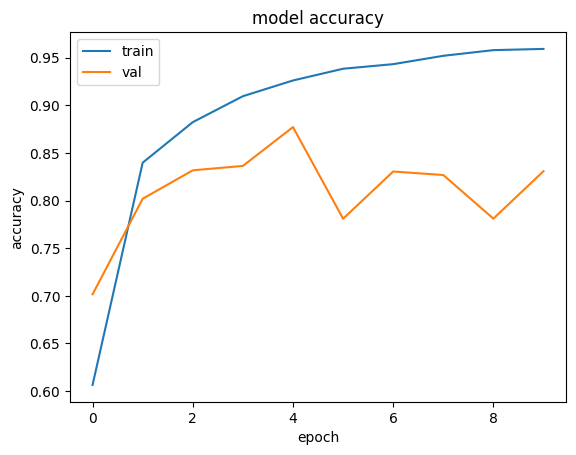

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

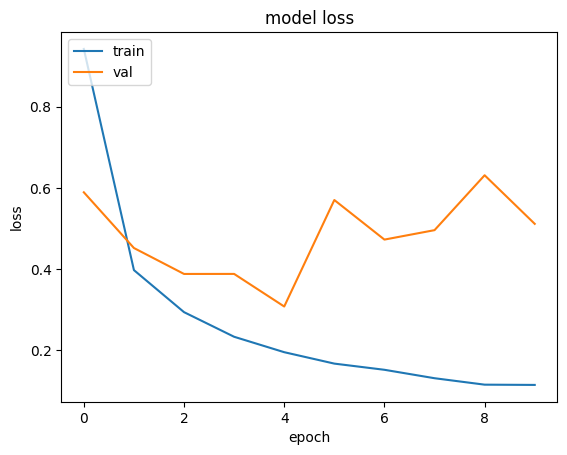

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_X_list, test_Y_list)

271/271 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.9009 - loss: 0.2828


In [ ]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X_list[0].shape)
print("Test Y shape:", test_Y_list[0].shape)

Test X shape: (8652, 80, 6)
Test Y shape: (8652, 5)


In [ ]:
#predictions
predictions = model.predict(test_X_list)

271/271 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step


In [ ]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y_list, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 84.94%
Predicted classes: [4 3 0 ... 4 1 1]
True classes: [[4 3 0 ... 4 4 4]
 [4 3 0 ... 4 4 4]
 [4 3 0 ... 4 4 4]
 ...
 [4 3 0 ... 4 4 4]
 [4 3 0 ... 4 4 4]
 [4 3 0 ... 4 4 4]]


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = np.array(predicted_classes)
true_classes_np = np.array(true_classes[0])

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print(f"Specificities (per class): {specificities}")

Classification Report:
               precision    recall  f1-score   support

           0     0.8786    0.7648    0.8178      1637
           1     0.6661    0.9696    0.7897      1251
           2     0.8986    0.9612    0.9288       387
           3     0.9168    0.9182    0.9175       660
           4     0.9019    0.8281    0.8634      4717

    accuracy                         0.8494      8652
   macro avg     0.8524    0.8884    0.8634      8652
weighted avg     0.8644    0.8494    0.8512      8652

Confusion Matrix:
 [[1252    0    0    0  385]
 [   1 1213    0    0   37]
 [  15    0  372    0    0]
 [   0   10   41  606    3]
 [ 157  598    1   55 3906]]
F1-Scores (per class): [0.76481368 0.9696243  0.96124031 0.91818182 0.82806869]
Specificities (per class): [0.9753385602280826, 0.9178489393325227, 0.9949183303085299, 0.9931181181181181, 0.8919949174078781]


## Confusion Matrix

In [ ]:
true_classes = true_classes[0].numpy()
predicted_classes = predicted_classes.numpy()

In [ ]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

In [ ]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

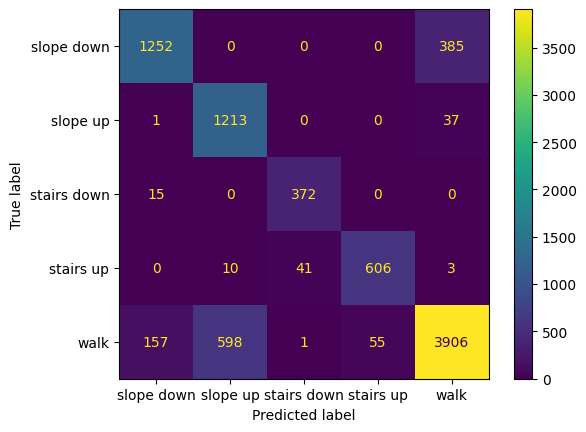

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot()
plt.show()

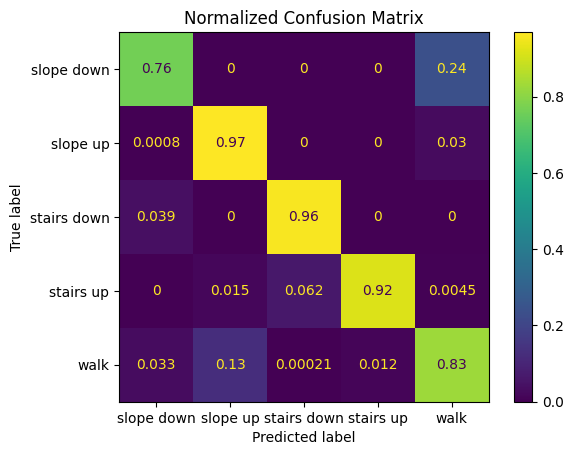

In [ ]:
# Create the confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [ ]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE